In [2]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import math
sys.path.append('../../')
from Scattering_Simulator import pairwise_method
from Scattering_Simulator import Read_PDB
from genetic_algorithm import GA_functions as GA
from genetic_algorithm import curve_fitting as cf
from scipy import integrate
import torch
plt.rcParams.update({'font.size': 18})

Text(0.5, 0, 'q ($\\AA^{-1}$)')

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

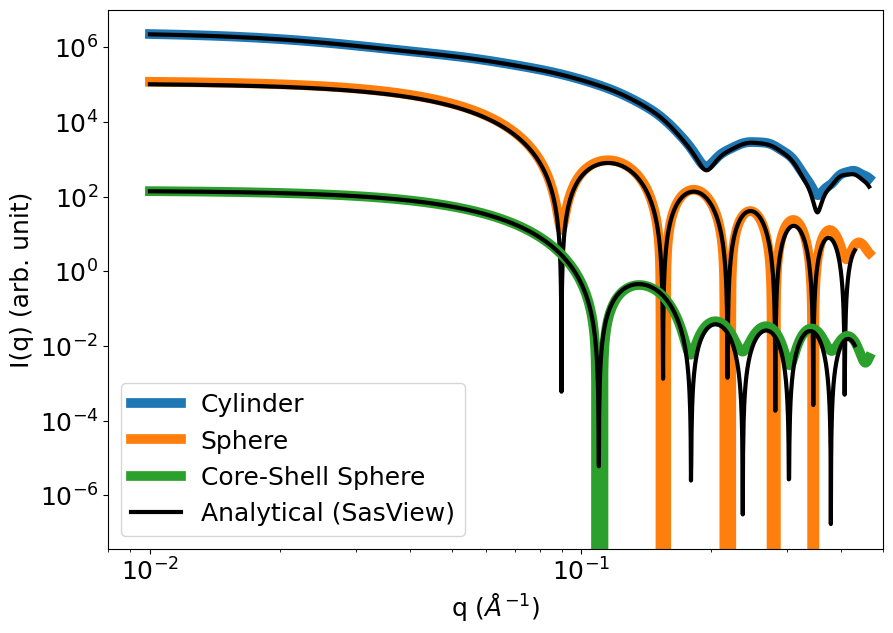

In [3]:
sim_data_sphere = pd.read_csv('../2026-04-11_17-55-45_sphere/Intensity.txt', delimiter=' ').values
sasview_data_sphere = pd.read_csv('../2026-04-11_17-55-45_sphere/sasview_intensity.txt', delimiter=' ').values

sim_data_rods = pd.read_csv('../2026-04-11_17-19-38_rods/Intensity.txt', delimiter=' ').values
sasview_data_rods = pd.read_csv('../2026-04-11_17-19-38_rods/sasview_intensity.txt', delimiter=' ').values


sim_data_coreshell = pd.read_csv('../2026-04-19_16-30-46_core_shell/Intensity.txt', delimiter=' ').values
sasview_data_coreshell = pd.read_csv('../2026-04-19_16-30-46_core_shell/sasview_intensity.txt', delimiter=' ').values

plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))
plt.loglog(sim_data_rods[0:-500,0], sim_data_rods[0:-500,1], color = 'C0', linewidth=7, label='Cylinder')
plt.loglog(sasview_data_rods[:-500,0], sasview_data_rods[:-500,1], color='k', linewidth=3)

plt.loglog(sim_data_sphere[0:-500,0], sim_data_sphere[0:-500,1]*1e-1, color = 'C1', linewidth=7, label='Sphere')
plt.loglog(sasview_data_sphere[:-550,0], sasview_data_sphere[:-550,1]*1e-1, color='k', linewidth=3)

plt.loglog(sim_data_coreshell[0:-500,0], sim_data_coreshell[0:-500,1]*1e-5, color = 'C2', linewidth=7, label='Core-Shell Sphere')
plt.loglog(sasview_data_coreshell[:-550,0], sasview_data_coreshell[:-550,1]*1e-5, color='k', label='Analytical (SasView)', linewidth=3)



plt.xlim([8e-3, 5e-1])
#plt.ylim([1e-4, 1e2])
plt.legend(loc='lower left')
plt.ylabel('I(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')

Text(0.5, 0, 'q ($\\AA^{-1}$)')

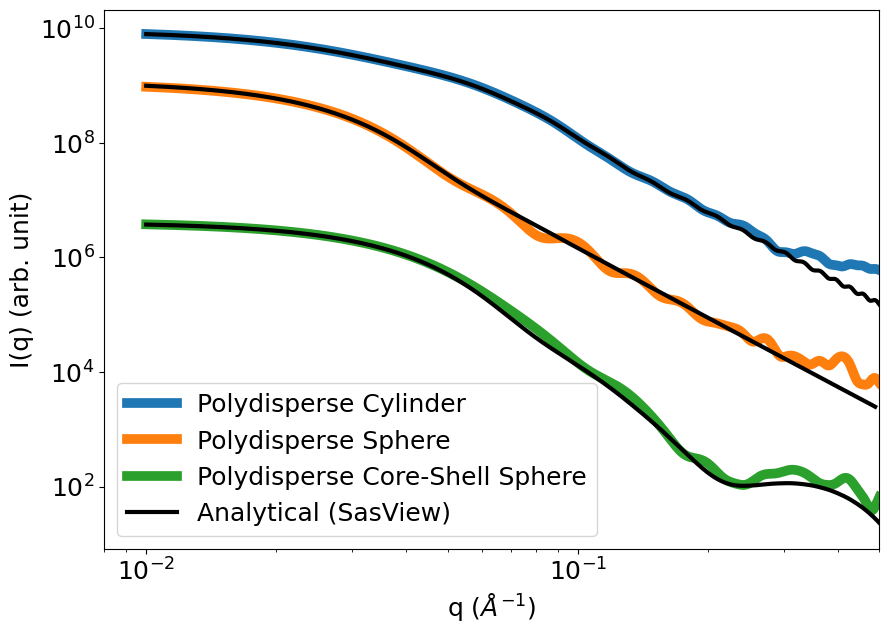

In [16]:
sim_data_rod_poly = pd.read_csv('../2026-07-17_12-39-29_Polydisperse_Rods/Intensity.txt', delimiter=' ').values
sasview_data_rod_poly = pd.read_csv('../2026-07-17_12-39-29_Polydisperse_Rods/sasview_intensity.txt', delimiter=' ').values

sim_data_sphere_poly = pd.read_csv('../2026-07-17_15-11-47_Sphere_Polydisperse/Intensity.txt', delimiter=' ').values
sasview_data_sphere_poly = pd.read_csv('../2026-07-17_15-11-47_Sphere_Polydisperse/sasview_intensity.txt', delimiter=' ').values

sim_data_core_shell_poly = pd.read_csv('../2026-07-17_12-58-51_Core_Shell_polydisperse/Intensity.txt', delimiter=' ').values
sasview_data_core_shell_poly = pd.read_csv('../2026-07-17_12-58-51_Core_Shell_polydisperse/sasview_intensity.txt', delimiter=' ').values



plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))
#plt.loglog(sim_data_rod_poly[1100:-500,0], sim_data_rod_poly[1100:-500,1], color = 'C0', linewidth=7, label='Polydisperse Rods')
#plt.loglog(sasview_data_rod_poly[50:,0], sasview_data_rod_poly[50:,1], color='k', linewidth=3)

plt.loglog(sim_data_rod_poly[:,0], sim_data_rod_poly[:,1], color = 'C0', linewidth=7, label='Polydisperse Cylinder')
plt.loglog(sasview_data_rod_poly[:,0], sasview_data_rod_poly[:,1]*4.6e3, color='k', linewidth=3)


plt.loglog(sim_data_sphere_poly[0:,0], sim_data_sphere_poly[0:,1]*1e-2, color = 'C1', linewidth=7, label='Polydisperse Sphere')
plt.loglog(sasview_data_sphere_poly[:,0], sasview_data_sphere_poly[:,1]*8e2, color='k', linewidth=3)


plt.loglog(sim_data_core_shell_poly[0:,0], sim_data_core_shell_poly[0:,1]*2e-4, color = 'C2', linewidth=7, label='Polydisperse Core-Shell Sphere')
plt.loglog(sasview_data_core_shell_poly[:,0], sasview_data_core_shell_poly[:,1]*3.5e-1, color='k', label='Analytical (SasView)', linewidth=3)



plt.xlim([8e-3, 5e-1])
#plt.ylim([1e-3, 1e7])
plt.legend(loc='lower left')
plt.ylabel('I(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')

Text(0.5, 0, 'q ($\\AA^{-1}$)')

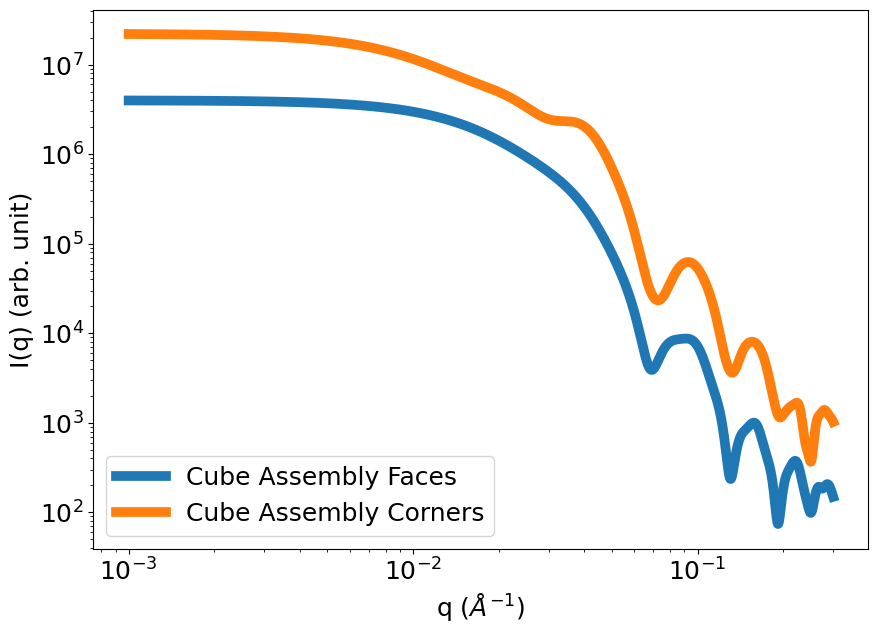

In [24]:
data_cube_face = pd.read_csv('../2026-05-11_22-23-31_Cube_Assembly_Face/Intensity.txt', delimiter=' ').values
data_cube_corner = pd.read_csv('../2026-05-11_22-19-16_Cube_Assembly_Corner/Intensity.txt', delimiter=' ').values

plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))


plt.loglog(data_cube_face[0:,0], data_cube_face[0:,1], color = 'C0', linewidth=7, label='Cube Assembly Faces')

plt.loglog(data_cube_corner[0:,0], data_cube_corner[0:,1]*3.5e0, color = 'C1', linewidth=7, label='Cube Assembly Corners')

#plt.xlim([8e-3, 5e-1])
#plt.ylim([1e-3, 1e7])
plt.legend(loc='lower left')
plt.ylabel('I(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')



Text(0.5, 0, 'q ($\\AA^{-1}$)')

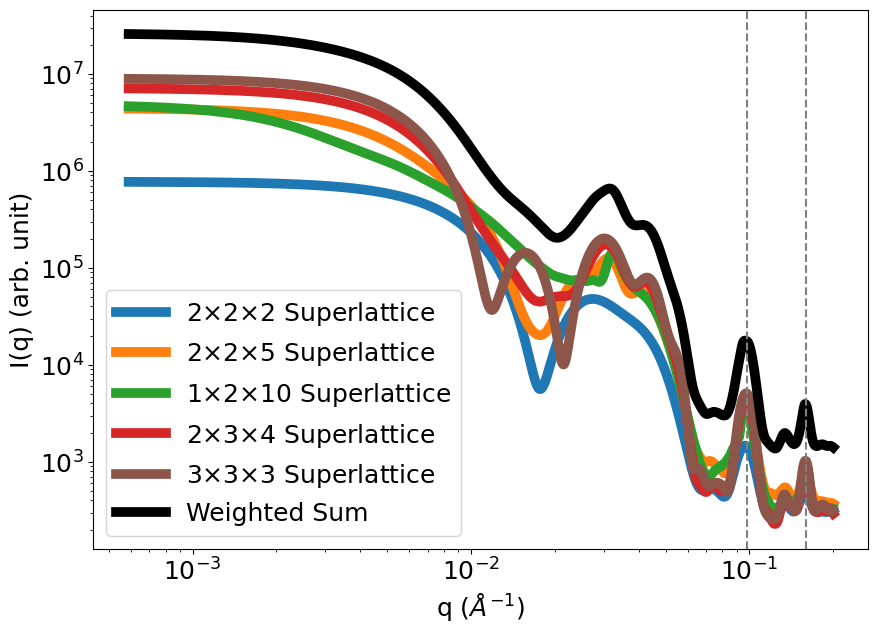

In [25]:
data_cube_superlattice_1 = pd.read_csv('../2026-05-23_19-50-56_Cube_Superlattice_Polydisperse_2/scaled_curve_2x2x2.txt', delimiter=' ').values[700:, :]
data_cube_superlattice_2 = pd.read_csv('../2026-05-23_19-50-56_Cube_Superlattice_Polydisperse_2/scaled_curve_2x5x2.txt', delimiter=' ').values[700:, :]
data_cube_superlattice_3 = pd.read_csv('../2026-05-23_19-50-56_Cube_Superlattice_Polydisperse_2/scaled_curve_3x3x3.txt', delimiter=' ').values[700:, :]
data_cube_superlattice_4 = pd.read_csv('../2026-05-23_19-50-56_Cube_Superlattice_Polydisperse_2/scaled_curve_3x4x2.txt', delimiter=' ').values[700:, :]
data_cube_superlattice_5 = pd.read_csv('../2026-05-23_19-50-56_Cube_Superlattice_Polydisperse_2/scaled_curve_10x2x1.txt', delimiter=' ').values[700:, :]

data_cube_superlattice_6 = pd.read_csv('../2026-05-23_19-50-56_Cube_Superlattice_Polydisperse_2/intensity.txt', delimiter=' ').values[700:, :]



plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))


# plt.loglog(data_cube_superlattice[0:,0], data_cube_superlattice[0:,1] + 4e2, color = 'C0', linewidth=7, label='Cube 3x3x3 Superlattice')

#plt.loglog(data_cube_superlattice_mixture[0:,0], data_cube_superlattice_mixture[0:,1]*1e2 + 4e2, color = 'C1', linewidth=7, label='Cube Superlattice Mixture')


plt.loglog(data_cube_superlattice_1[0:,0], data_cube_superlattice_1[0:,1] + 3e2, color='C0', linewidth=7, label='2$\\times$2$\\times$2 Superlattice')
plt.loglog(data_cube_superlattice_2[0:,0], data_cube_superlattice_2[0:,1] + 3e2, color='C1', linewidth=7, label='2$\\times$2$\\times$5 Superlattice')
plt.loglog(data_cube_superlattice_5[0:,0], data_cube_superlattice_5[0:,1] + 3e2, color='C2', linewidth=7, label='1$\\times$2$\\times$10 Superlattice')
plt.loglog(data_cube_superlattice_4[0:,0], data_cube_superlattice_4[0:,1] + 3e2, color='C3', linewidth=7, label='2$\\times$3$\\times$4 Superlattice')
plt.loglog(data_cube_superlattice_3[0:,0], data_cube_superlattice_3[0:,1] + 3e2, color='C5', linewidth=7, label='3$\\times$3$\\times$3 Superlattice')
plt.loglog(data_cube_superlattice_6[0:,0], data_cube_superlattice_6[0:,1] + 3e2, color='k', linewidth=7, label= 'Weighted Sum')




#plt.axvline(x=0.043, color='red', linestyle='--')
plt.axvline(x=0.098, color='gray', linestyle='--')
plt.axvline(x=0.160, color='gray', linestyle='--')
#plt.xlim([8e-3, 5e-1])
#plt.ylim([1e-3, 1e7])
plt.legend(loc='lower left')
plt.ylabel('I(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')



(1e-12, 10000.0)

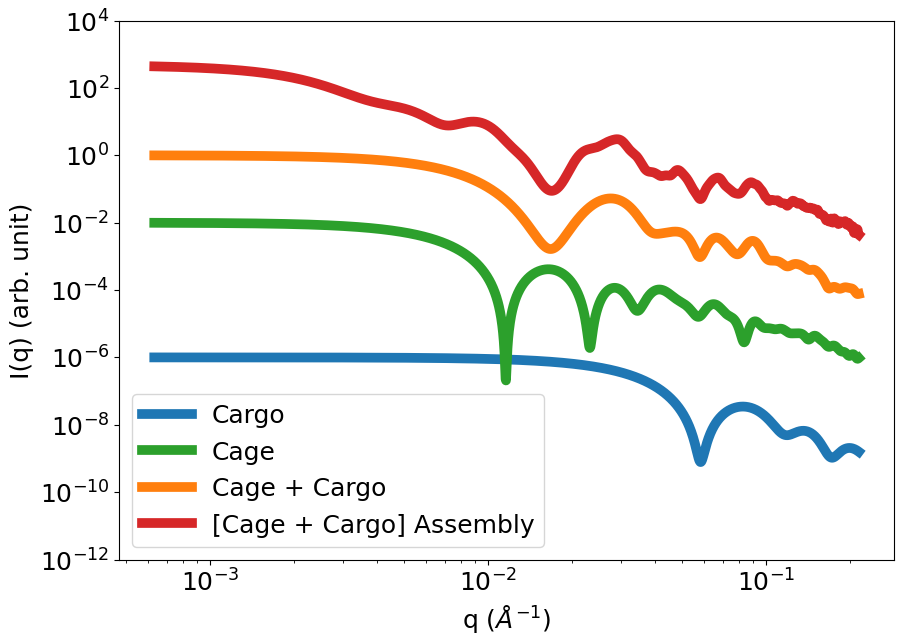

In [26]:
data_protein_large = pd.read_csv('../2026-05-28_00-31-15_Proteins/Intensity_large_protein.txt', delimiter=' ').values[600:-500,:]
data_protein_small = pd.read_csv('../2026-05-28_00-31-15_Proteins/Intensity_small_protein.txt', delimiter=' ').values[600:-500,:]

data_protein_multicomponent = pd.read_csv('../2026-05-28_00-35-57_Protein_Multicomponent/Intensity.txt', delimiter=' ').values[600:-500,:]
data_protein_multicomponent_assembly = pd.read_csv('../2026-05-28_00-47-57_Protein_Multicomponent_Assembly/Intensity.txt', delimiter=' ').values[600:-500,:]





plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))


plt.loglog(data_protein_small[0:,0], data_protein_small[0:,1]*1e-6, color = 'C0', linewidth=7, label='Cargo')
plt.loglog(data_protein_large[0:,0], data_protein_large[0:,1]*1e-2 + 5e-7, color = 'C2', linewidth=7, label='Cage')
plt.loglog(data_protein_multicomponent[0:,0], data_protein_multicomponent[0:,1], color = 'C1', linewidth=7, label='Cage + Cargo')
plt.loglog(data_protein_multicomponent_assembly[0:,0], data_protein_multicomponent_assembly[0:,1]*1e-5, color = 'C3', linewidth=7, label='[Cage + Cargo] Assembly')

#plt.loglog(data_protein_assembly_SLD[0:,0], data_protein_assembly_SLD[0:,1]*5e-14, color = 'C1', linewidth=7, label='Non-uniform SLD Contrast')

#plt.xlim([8e-3, 5e-1])
#plt.ylim([1e-3, 1e7])
plt.legend(loc='lower left')
plt.ylabel('I(q) (arb. unit)')
plt.xlabel('q ($\\AA^{-1}$)')
plt.ylim([1e-12, 1e4])
